[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/probability_statistics/04_discrete_distributions/first_principles.ipynb)

# Module 04 — Discrete Distributions

## 1. Why This Module Exists

Counting is the oldest form of measurement. How many clicks did the ad receive? How many photons hit the detector in one millisecond? How many attempts before the compiler finally builds? Each such question produces a random variable with values in $\{0, 1, 2, \ldots\}$, and — remarkably — a small handful of probability laws answers almost all of them.

The reason is that these laws are not invented; they are *forced*. Fix a generative story precisely enough and the PMF follows by pure counting. "Independent trials, constant success probability, count successes" leaves no freedom: the answer must be Binomial. "Independent trials, constant success probability, count trials until the first success" must be Geometric. "Events arriving at constant rate, never simultaneously, with non-overlapping windows independent" must be Poisson. The formulas are theorems about the stories, not modeling choices layered on top of them.

This is why the practical skill in this module is *story matching*. Choosing a Poisson model asserts independence and rarity; choosing a Binomial asserts a fixed number of homogeneous trials; choosing a Geometric asserts memorylessness. When data contradicts the assertion — most commonly through **overdispersion**, $\mathrm{Var}(X) \gt E[X]$ where Poisson demands equality — the fix is to change the story (mix the rate, allow clustering), not to patch the formula.

Machine learning runs on these laws directly. Every softmax classifier head is a Categorical likelihood; every language model emits one Categorical per token; every count regression is a Poisson or Negative Binomial GLM; dropout is Bernoulli noise. Getting the family wrong is not a cosmetic error — Example 6.2 and the tail comparison in the exercises show it costs orders of magnitude exactly in the tail, where decisions are made.

## 2. Intuition

### 2.1 Everything Is Built From Bernoulli Atoms

A single binary trial, $X \in \{0, 1\}$ with $P(X = 1) = p$, is the indivisible unit of discrete probability. From it:

- **Sum $n$ of them** (independent, same $p$): the count is $\text{Binomial}(n, p)$.
- **Sum $n$ of them without replacement from a finite urn**: the count is $\text{Hypergeometric}$.
- **Wait for the first 1**: the waiting time is $\text{Geometric}(p)$.
- **Wait for the $r$-th 1**: the waiting time is $\text{Negative Binomial}(r, p)$.
- **Let $n \to \infty$, $p \to 0$ with $np \to \lambda$**: the count converges to $\text{Poisson}(\lambda)$.
- **Replace two outcomes by $K$**: one trial is $\text{Categorical}(\mathbf{p})$, $n$ trials give $\text{Multinomial}(n, \mathbf{p})$.

Two tools then extract everything else. **Indicator decomposition** ($X = \sum_i \mathbf{1}_i$) plus linearity of expectation gives means with no independence assumption whatsoever. **Generating functions** — the PGF $G_X(s) = E[s^X]$ and the MGF $M_X(t) = E[e^{tX}]$ — turn convolution into multiplication and differentiation into moment extraction, which is how sums of independent counts and all higher moments are computed mechanically.

### 2.2 The Mean Does Not Identify the Family

The single most useful mental picture is that the mean is almost no information at all. Six different stories can produce the same average count and wildly different spreads, and the spread is what the story controls. Sampling without replacement *removes* variance (the urn is finite, so draws anti-correlate); mixing the rate *adds* variance (units differ); waiting times are long-tailed because a rare early failure costs many trials. The figure below draws six canonical families all pinned to mean $3$ and orders them by variance — the variance-to-mean ratio is the fingerprint that names the story.

The first code cell is the module preamble: imports, plotting defaults, and the single random generator `rng` used everywhere below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb, lgamma, exp, pi
from scipy.stats import binom, poisson, hypergeom, nbinom, geom, randint, norm
from scipy.special import gammaln

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

print("preamble ready")

preamble ready


**Figure (Section 2).** Six canonical families, every one with mean exactly $3$, drawn on a common
support and sorted by variance. The legend prints each variance so the ordering is checkable.

Hypergeometric(48, 12, 12)             mean =  3.000   var =  1.723   var/mean = 0.574
Binomial(12, 0.25)                     mean =  3.000   var =  2.250   var/mean = 0.750
Poisson(3)                             mean =  3.000   var =  3.000   var/mean = 1.000
Uniform{0,...,6}                       mean =  3.000   var =  4.000   var/mean = 1.333
Geometric(1/3) on {1,2,...}            mean =  3.000   var =  6.000   var/mean = 2.000
NegBinomial(r=2, p=0.4), failures      mean =  3.000   var =  7.500   var/mean = 2.500


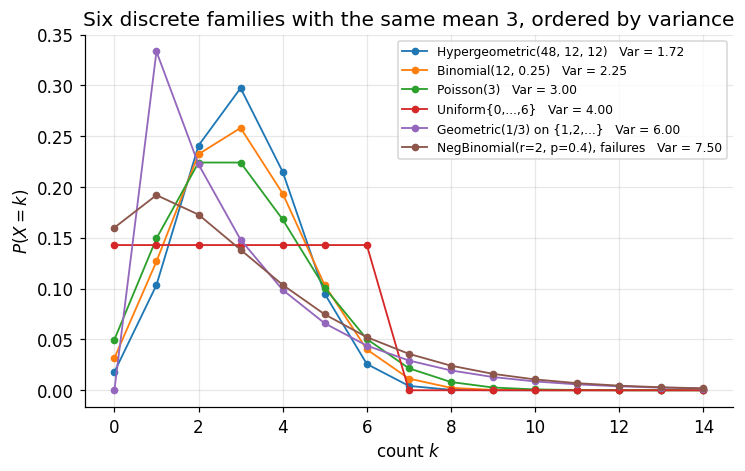

In [2]:
k_full = np.arange(0, 600)          # long grid: moments must not be truncated
k_plot = np.arange(0, 15)           # short grid: what the eye needs

families = [
    ("Hypergeometric(48, 12, 12)", hypergeom.pmf(k_full, 48, 12, 12)),
    ("Binomial(12, 0.25)",         binom.pmf(k_full, 12, 0.25)),
    ("Poisson(3)",                 poisson.pmf(k_full, 3.0)),
    ("Uniform{0,...,6}",           randint.pmf(k_full, 0, 7)),
    ("Geometric(1/3) on {1,2,...}", geom.pmf(k_full, 1 / 3)),
    ("NegBinomial(r=2, p=0.4), failures", nbinom.pmf(k_full, 2, 0.4)),
]

rows = []
for name, pmf in families:
    m = float(np.sum(k_full * pmf))
    v = float(np.sum((k_full - m) ** 2 * pmf))
    rows.append((name, m, v))
    print(f"{name:38s} mean = {m:6.3f}   var = {v:6.3f}   var/mean = {v/m:5.3f}")
    assert abs(m - 3.0) < 1e-6

order = np.argsort([v for _, _, v in rows])
fig, ax = plt.subplots(figsize=(7.6, 4.4))
for idx in order:
    name, m, v = rows[idx]
    ax.plot(k_plot, families[idx][1][: len(k_plot)], marker="o", ms=4, lw=1.2,
            label=f"{name}   Var = {v:.2f}")
ax.set_xlabel("count $k$")
ax.set_ylabel("$P(X = k)$")
ax.set_title("Six discrete families with the same mean 3, ordered by variance")
ax.legend(fontsize=8)
plt.show()

Every curve has mean exactly $3$ (asserted in the cell), yet the variances run from $1.72$
(Hypergeometric, where the finite urn suppresses fluctuation) through $3.00$ (Poisson, the
equidispersed reference) up to $7.50$ (Negative Binomial, where a mixed rate inflates the tail). The dispersion index
$\mathrm{Var}/E$ printed above is therefore a family classifier: below $1$ means "fixed budget of
trials", exactly $1$ means Poisson, above $1$ means heterogeneity or clustering.

## 3. Definitions

**Definition 3.1 (Bernoulli).** $X \sim \text{Bernoulli}(p)$, $p \in [0,1]$, if

$$
P(X = 1) = p, \qquad P(X = 0) = 1 - p,
$$

compactly $p_X(k) = p^k (1-p)^{1-k}$ for $k \in \{0,1\}$.

**Definition 3.2 (Binomial).** If $X_1, \ldots, X_n$ are i.i.d. $\text{Bernoulli}(p)$ and $S_n = \sum_{i=1}^n X_i$, then $S_n \sim \text{Binomial}(n, p)$ with

$$
P(S_n = k) = \binom{n}{k} p^k (1-p)^{n-k}, \qquad k = 0, 1, \ldots, n.
$$

The binomial coefficient counts the orderings of $k$ successes among $n$ slots; the powers give the probability of any one such ordering.

**Definition 3.3 (Hypergeometric).** Draw $n$ items without replacement from a finite population of $N$ items containing $K$ "successes". The count $X$ of successes drawn is $X \sim \text{Hypergeometric}(N, K, n)$ with

$$
P(X = k) = \frac{\binom{K}{k}\binom{N-K}{n-k}}{\binom{N}{n}}, \qquad \max(0, n-N+K) \le k \le \min(n, K).
$$

This is the law behind capture–recapture: tag $K$ of $N$ fish, recapture $n$, and $X$ counts the tagged fish recaptured.

**Definition 3.4 (Geometric and Negative Binomial, *trials* convention).** With i.i.d. $\text{Bernoulli}(p)$ trials, $p \gt 0$, let $T$ be the index of the first success. Then $T \sim \text{Geometric}(p)$ with

$$
P(T = k) = (1-p)^{k-1} p, \qquad k = 1, 2, \ldots
$$

Let $T_r$ be the index of the $r$-th success, $r \in \{1, 2, \ldots\}$. Then $T_r \sim \text{NegBinomial}(r, p)$ with

$$
P(T_r = k) = \binom{k-1}{r-1} p^r (1-p)^{k-r}, \qquad k = r, r+1, \ldots
$$

**Definition 3.5 (Negative Binomial, *failures* convention).** For any real $r \gt 0$ and $p \in (0,1)$, the failures-convention Negative Binomial is the law on $\{0, 1, 2, \ldots\}$ with

$$
P(X = k) = \frac{\Gamma(k+r)}{\Gamma(r)\,k!}\,p^r (1-p)^{k}, \qquad k = 0, 1, 2, \ldots
$$

When $r$ is a positive integer, $\Gamma(k+r)/(\Gamma(r)k!) = \binom{k+r-1}{k}$ and $X = T_r - r$ counts the failures preceding the $r$-th success, so Definitions 3.4 and 3.5 describe the same experiment shifted by $r$. **The two conventions are not interchangeable**: Definition 3.4 lives on $\{r, r+1, \ldots\}$ with integer $r$, Definition 3.5 lives on $\{0, 1, \ldots\}$ with arbitrary real $r \gt 0$. Theorem 4.7 and every mixture statement below use Definition 3.5, because a mixture produces non-integer $r$ and puts mass at $0$.

**Definition 3.6 (Poisson).** $X \sim \text{Poisson}(\lambda)$, $\lambda \gt 0$, if

$$
P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}, \qquad k = 0, 1, 2, \ldots
$$

Normalization is the exponential series, $\sum_{k \ge 0} \lambda^k / k! = e^{\lambda}$.

**Definition 3.7 (Categorical and Multinomial).** Let $\mathbf{p} = (p_1, \ldots, p_K)$ lie in the simplex $\Delta^{K-1} = \{\mathbf{p} : p_j \ge 0, \sum_j p_j = 1\}$. A single $K$-way trial $Y \in \{1, \ldots, K\}$ with $P(Y = j) = p_j$ is $\text{Categorical}(\mathbf{p})$. The vector of counts $\mathbf{N} = (N_1, \ldots, N_K)$ from $n$ i.i.d. such trials is $\text{Multinomial}(n, \mathbf{p})$:

$$
P(\mathbf{N} = \mathbf{n}) = \frac{n!}{n_1!\,n_2!\cdots n_K!} \prod_{j=1}^K p_j^{n_j}, \qquad \sum_j n_j = n.
$$

**Definition 3.8 (Generating functions).** For a non-negative integer-valued $X$, the *probability generating function* and *moment generating function* are

$$
G_X(s) = E\left[s^X\right] = \sum_{k \ge 0} p_X(k) s^k \quad (\lvert s \rvert \le 1), \qquad M_X(t) = E\left[e^{tX}\right] = G_X(e^t).
$$

**Definition 3.9 (Total variation and $\ell_1$ distance).** For laws $\mu, \nu$ on $\{0,1,2,\ldots\}$,

$$
d_{\mathrm{TV}}(\mu, \nu) = \sup_{A} \lvert \mu(A) - \nu(A) \rvert = \tfrac{1}{2}\sum_{k \ge 0}\lvert \mu(k) - \nu(k)\rvert = \tfrac12 \lVert \mu - \nu \rVert_1 .
$$

The factor $\tfrac12$ is the whole content of Definition 3.9 and the single most common source of factor-of-two errors in Poisson approximation: a bound quoted for $\lVert \cdot \rVert_1$ is twice the bound for $d_{\mathrm{TV}}$.

**Definition 3.10 (Dispersion index).** For $X$ with $E[X] \gt 0$, the Fisher index of dispersion is $D(X) = \mathrm{Var}(X)/E[X]$.

## 4. Main Results

### Theorem 4.1 (Generating-function toolkit)

Let $X, Y$ be non-negative integer-valued.

1. $G_X$ determines the law: $p_X(k) = G_X^{(k)}(0)/k!$.
2. If $E[X^2] \lt \infty$ then $E[X] = G_X'(1)$ and $\mathrm{Var}(X) = G_X''(1) + G_X'(1) - G_X'(1)^2$.
3. If $X$ and $Y$ are **independent**, then $G_{X+Y} = G_X G_Y$ and $M_{X+Y} = M_X M_Y$.

*Hypotheses.* Non-negativity and integrality make $G_X$ a power series with radius of convergence at least $1$, which is what licenses (1) — without it the coefficients are not recoverable by differentiation at $0$. The second-moment assumption in (2) is what makes $G_X''(1)$ exist as a one-sided limit; a heavy-tailed law such as $p_X(k) \propto k^{-2}$ has $G_X'(1) = \infty$. Independence in (3) is essential: it is exactly the statement $E[s^X s^Y] = E[s^X]E[s^Y]$, which fails for correlated summands.

### Theorem 4.2 (Binomial moments, and closure under addition)

Let $S_n \sim \text{Binomial}(n, p)$. Then

$$
\boxed{E[S_n] = np, \qquad \mathrm{Var}(S_n) = np(1-p), \qquad G_{S_n}(s) = (1 - p + ps)^n .}
$$

Moreover if $X \sim \text{Binomial}(m, p)$ and $Y \sim \text{Binomial}(n, p')$ are independent, then $X + Y$ is Binomial **if and only if** $p = p'$, in which case $X + Y \sim \text{Binomial}(m+n, p)$.

**Interpretation.** The mean is a statement about one trial repeated $n$ times and needs nothing but linearity — it survives dependence, which is why the Hypergeometric of Definition 3.3 has the same mean. The variance is where independence is spent: it is the sum of $n$ per-trial variances with all covariances zero. The consequence for modeling is that pooling two Binomial counts is legitimate only when the two experiments share a success probability; pooling across heterogeneous $p$ produces a Poisson-binomial law whose variance $\sum_i p_i(1-p_i)$ is strictly smaller than that of any Binomial with the same mean.

*Hypotheses.* Identical $p$ across trials is required for the count to be Binomial at all; independence is required for the variance and for the PGF factorization; the "same $p$" condition in the closure statement is required because $(1-p+ps)^m(1-p'+p's)^n$ has two distinct roots in $s$ when $p \neq p'$ and therefore cannot equal $(1-\pi+\pi s)^{m+n}$.

### Theorem 4.3 (Poisson MGF, moments, additivity)

If $X \sim \text{Poisson}(\lambda)$ then

$$
\boxed{M_X(t) = \exp\left(\lambda(e^t - 1)\right) \ \ (t \in \mathbb{R}), \qquad E[X] = \mathrm{Var}(X) = \lambda, \qquad D(X) = 1 .}
$$

If $X \sim \text{Poisson}(\lambda_1)$ and $Y \sim \text{Poisson}(\lambda_2)$ are **independent**, then $X + Y \sim \text{Poisson}(\lambda_1 + \lambda_2)$.

**Interpretation.** The MGF is finite for every real $t$, so a Poisson has moments of all orders and exponential tail bounds apply to it (this is what Problem L3.1 exploits). Equidispersion $D(X) = 1$ is not a convenience but a *falsifiable prediction*: count data with dispersion index $3$ is evidence against the Poisson story, not noisy Poisson data. Additivity requires independence — two perfectly correlated Poissons sum to a law with variance $4\lambda$, not $2\lambda$.

### Theorem 4.4 (Poisson limit theorem — law of rare events)

Let $X_n \sim \text{Binomial}(n, p_n)$ with $n p_n \to \lambda \in (0, \infty)$ as $n \to \infty$. Then for every fixed $k \ge 0$,

$$
\boxed{P(X_n = k) \longrightarrow \frac{\lambda^k e^{-\lambda}}{k!} .}
$$

**Interpretation.** Rarity is doing the work, not sample size. The hypothesis $np_n \to \lambda$ forces $p_n \to 0$: many trials, each nearly impossible, moderate expected count. Drop it — hold $p$ fixed and send $n \to \infty$ — and the limit is Gaussian by the central limit theorem, not Poisson; the code cell in Section 7.3 exhibits exactly this breakage. The consequence is that "large $n$" is never on its own a reason to reach for a Poisson.

*Hypotheses.* $np_n \to \lambda \in (0,\infty)$ is needed twice: the finite positive limit fixes the target parameter, and it forces $p_n \to 0$, which is what makes the factor $(1-p_n)^{-k}$ negligible. "$k$ fixed" is needed because the convergence is pointwise in $k$, not uniform in the tail.

### Theorem 4.5 (Le Cam's bound)

Let $S = \sum_{i=1}^n B_i$ with **independent** $B_i \sim \text{Bernoulli}(p_i)$ and $\lambda = \sum_{i=1}^n p_i$, and let $\Pi_\lambda$ denote the $\text{Poisson}(\lambda)$ law. Then

$$
\boxed{d_{\mathrm{TV}}\left(S, \Pi_\lambda\right) \le \sum_{i=1}^n p_i^2, \qquad \text{equivalently} \qquad \sum_{k \ge 0}\left\lvert P(S = k) - \frac{\lambda^k e^{-\lambda}}{k!}\right\rvert \le 2\sum_{i=1}^n p_i^2 .}
$$

**Interpretation.** This is Theorem 4.4 made non-asymptotic and freed of the identical-distribution assumption: no limit is taken, $n$ never appears except through $\lambda$ and the $p_i$, and since $\sum_i p_i^2 \le \lambda \max_i p_i$ the accuracy is governed by the *largest* single-trial probability. Quote the two forms carefully: the $\ell_1$ number is twice the total-variation number, by Definition 3.9.

*Hypotheses.* Independence is essential — the proof couples the coordinates one at a time and takes a union bound, which needs a product construction; with dependence the sum can be arbitrarily far from Poisson (a single Bernoulli repeated $n$ times gives $S \in \{0, n\}$).

### Theorem 4.6 (Discrete memorylessness characterizes the Geometric)

Let $T$ be a random variable on $\{1, 2, \ldots\}$ with $P(T \lt \infty) = 1$. Then

$$
P(T \gt m + n \mid T \gt m) = P(T \gt n) \quad \text{for all integers } m, n \ge 0
$$

**if and only if** $T \sim \text{Geometric}(p)$ for some $p \in (0, 1]$.

*Hypotheses.* $P(T \lt \infty) = 1$ excludes the degenerate solution $S(n) = P(T \gt n) \equiv 1$ of the same functional equation, which corresponds to $T = +\infty$ almost surely and is not a random variable on $\{1,2,\ldots\}$; without it the "only if" direction is false. Integrality of the support is what turns the Cauchy functional equation $S(m+n) = S(m)S(n)$ into a solvable induction with no regularity assumption — the continuous analogue needs measurability to exclude pathological solutions.

**Interpretation.** Memorylessness is the entire content of the Geometric law: a used component is as good as new. Operationally it is what makes first-step arguments close (Proof 5.6) and what makes the gambler's fallacy a fallacy.

### Theorem 4.7 (Thinning and Gamma-mixing)

1. **Thinning.** Let $N \sim \text{Poisson}(\lambda)$ and, given $N = n$, let $M \sim \text{Binomial}(n, q)$ — each event is retained independently with probability $q$. Then $M \sim \text{Poisson}(\lambda q)$ and $N - M \sim \text{Poisson}(\lambda(1-q))$, and $M$ and $N - M$ are **independent**.
2. **Mixing.** Let $X \mid \Lambda \sim \text{Poisson}(\Lambda)$ with $\Lambda \sim \text{Gamma}(r, \beta)$ (shape $r \gt 0$, rate $\beta \gt 0$). Then $X$ has the failures-convention Negative Binomial law of Definition 3.5 with parameter $p = \beta/(1+\beta)$, and

$$
\boxed{E[X] = \frac{r}{\beta}, \qquad \mathrm{Var}(X) = \frac{r}{\beta} + \frac{r}{\beta^{2}} = E[X] + \mathrm{Var}(\Lambda) \gt E[X] .}
$$

**Interpretation.** Thinning says a lossy detector does not distort Poisson statistics, it only rescales the rate — which is why photon counting survives quantum efficiency below $1$. Mixing says the opposite for heterogeneity: any genuine randomness in the rate adds *exactly* $\mathrm{Var}(\Lambda)$ to the variance, so overdispersion measures latent rate spread rather than measurement noise. Setting $\mathrm{Var}(X) = \mu + \mu^2/r$ with $\mu = r/\beta$ recovers the NB2 parameterization used by every count-regression package.

*Hypotheses.* Thinning needs the retention decisions to be independent of each other and of $N$; if retention is triggered by the same burst that produced the events, $M$ and $N - M$ are correlated and neither is Poisson. Mixing needs $\Lambda$ to be non-degenerate for the strict inequality: $\mathrm{Var}(\Lambda) = 0$ returns the plain Poisson.

### Theorem 4.8 (Hypergeometric moments and Binomial limit)

Let $X \sim \text{Hypergeometric}(N, K, n)$ and write $f = K/N$. Then

$$
\boxed{E[X] = nf, \qquad \mathrm{Var}(X) = nf(1-f)\,\frac{N-n}{N-1} .}
$$

If $N \to \infty$ and $K = K(N)$ with $K/N \to p \in (0,1)$, then for fixed $n$ and each fixed $k$, $P(X = k) \to \binom{n}{k}p^k(1-p)^{n-k}$.

**Interpretation.** The factor $(N-n)/(N-1) \le 1$ is the **finite-population correction**: sampling without replacement removes variance, because the draws are negatively correlated — every success drawn makes the next success less likely. It equals $1$ when $n = 1$ (one draw cannot correlate with itself) and $0$ when $n = N$ (a census has no randomness left). As the population dwarfs the sample the correction tends to $1$ and the draws become effectively independent, which is the Binomial limit.

*Hypotheses.* $n \le N$ and $K \le N$ for the law to exist; $N \to \infty$ with $n$ **fixed** for the limit — if $n$ grows proportionally to $N$ the correction does not vanish and the limit is not Binomial.

### Table 4.1 — the canonical families

| Family | PMF | Mean | Variance | PGF $G(s)$ |
|---|---|---|---|---|
| Bernoulli($p$) | $p^k(1-p)^{1-k}$ | $p$ | $p(1-p)$ | $1 - p + ps$ |
| Binomial($n,p$) | $\binom{n}{k}p^k(1-p)^{n-k}$ | $np$ | $np(1-p)$ | $(1 - p + ps)^n$ |
| Hypergeometric($N,K,n$) | $\binom{K}{k}\binom{N-K}{n-k}/\binom{N}{n}$ | $nK/N$ | $n\frac{K}{N}\left(1-\frac{K}{N}\right)\frac{N-n}{N-1}$ | — |
| Geometric($p$), trials | $(1-p)^{k-1}p$ | $1/p$ | $(1-p)/p^2$ | $ps / (1 - (1-p)s)$ |
| NegBinomial($r,p$), trials (Def. 3.4) | $\binom{k-1}{r-1}p^r(1-p)^{k-r}$ | $r/p$ | $r(1-p)/p^2$ | $\left(ps / (1 - (1-p)s)\right)^r$ |
| NegBinomial($r,p$), failures (Def. 3.5) | $\frac{\Gamma(k+r)}{\Gamma(r)k!}p^r(1-p)^{k}$ | $r(1-p)/p$ | $r(1-p)/p^2$ | $\left(p / (1 - (1-p)s)\right)^r$ |
| Poisson($\lambda$) | $\lambda^k e^{-\lambda}/k!$ | $\lambda$ | $\lambda$ | $e^{\lambda(s-1)}$ |
| Discrete uniform on $\{0,\ldots,m\}$ | $1/(m+1)$ | $m/2$ | $\left((m+1)^2-1\right)/12$ | $\frac{1}{m+1}\frac{1-s^{m+1}}{1-s}$ |
| Multinomial($n,\mathbf{p}$) | $\frac{n!}{\prod_j n_j!}\prod_j p_j^{n_j}$ | $np_j$ | $np_j(1-p_j)$ | $\left(\sum_j p_j s_j\right)^n$ |

The Multinomial also satisfies $\mathrm{Cov}(N_i, N_j) = -n p_i p_j$ for $i \ne j$: counts compete for a fixed budget of $n$ trials, so they are *negatively* correlated.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1)

Since $0 \le p_X(k) \le 1$ and $\sum_k p_X(k) = 1$, the series $G_X(s) = \sum_k p_X(k)s^k$ converges absolutely for $\lvert s \rvert \le 1$, so it is a power series with radius of convergence at least $1$. Term-by-term differentiation inside the radius gives $G_X^{(k)}(0) = k!\,p_X(k)$, which is (1).

For (2), differentiating inside $\lvert s \rvert \lt 1$ gives $G_X'(s) = \sum_{k \ge 1} k\,p_X(k)s^{k-1}$, a series with non-negative terms; by monotone convergence its limit as $s \uparrow 1$ is $\sum_k k\,p_X(k) = E[X]$, finite by hypothesis. The same argument applied twice gives $G_X''(1) = E[X(X-1)]$, so

$$
G_X''(1) + G_X'(1) - G_X'(1)^2 = E[X^2] - E[X] + E[X] - E[X]^2 = \mathrm{Var}(X).
$$

For (3), independence gives $E[s^{X+Y}] = E[s^X s^Y] = E[s^X]E[s^Y]$ for $\lvert s \rvert \le 1$; setting $s = e^t$ gives the MGF statement. $\blacksquare$

### Proof 5.2 (of Theorem 4.2)

**Moments by indicator decomposition.** Write $S_n = \sum_{i=1}^n X_i$ with $X_i \sim \text{Bernoulli}(p)$ independent. For the mean only linearity is needed — **no independence at all**:

$$
E[S_n] = \sum_{i=1}^n E[X_i] = np.
$$

For the variance, independence enters. Since $X_i^2 = X_i$ (indicators are idempotent), $E[X_i^2] = p$, hence $\mathrm{Var}(X_i) = p - p^2 = p(1-p)$, and independence makes every covariance vanish:

$$
\mathrm{Var}(S_n) = \sum_{i=1}^n \mathrm{Var}(X_i) + 2\sum_{i \lt j} \mathrm{Cov}(X_i, X_j) = np(1-p) + 0 .
$$

**PGF.** For one Bernoulli, $G(s) = (1-p)s^0 + p s^1 = 1 - p + ps$; by Theorem 4.1(3), $G_{S_n}(s) = (1 - p + ps)^n$. Differentiating, $G'(1) = np$ and $G''(1) = n(n-1)p^2$, so Theorem 4.1(2) reproduces $\mathrm{Var}(S_n) = n(n-1)p^2 + np - n^2p^2 = np(1-p)$ — an independent check of the indicator computation.

**Closure.** If $p = p'$ then $G_{X+Y}(s) = (1-p+ps)^{m+n}$, the PGF of $\text{Binomial}(m+n,p)$, and Theorem 4.1(1) identifies the law. Conversely suppose $X + Y \sim \text{Binomial}(N, \pi)$ for some $N, \pi$. Then

$$
(1-p+ps)^m (1-p'+p's)^n = (1-\pi+\pi s)^N
$$

as polynomials in $s$. The right side has the single root $s = 1 - 1/\pi$ with multiplicity $N$; the left side has roots $1 - 1/p$ (multiplicity $m$) and $1 - 1/p'$ (multiplicity $n$). Equality of polynomials forces the root sets to agree, hence $p = p'$. $\blacksquare$

### Proof 5.3 (of Theorem 4.3)

Directly from the series, valid for every real $t$ because the exponential series converges everywhere:

$$
M_X(t) = \sum_{k \ge 0} e^{tk}\frac{\lambda^k e^{-\lambda}}{k!} = e^{-\lambda}\sum_{k \ge 0}\frac{(\lambda e^t)^k}{k!} = e^{-\lambda} e^{\lambda e^t} = \exp\left(\lambda(e^t - 1)\right).
$$

Differentiate: $M_X'(t) = \lambda e^t M_X(t)$, so $E[X] = M_X'(0) = \lambda$. Differentiating again,

$$
M_X''(t) = \lambda e^t M_X(t) + \lambda^2 e^{2t} M_X(t) \implies E[X^2] = \lambda + \lambda^2 \implies \mathrm{Var}(X) = \lambda .
$$

Additivity: by Theorem 4.1(3), $M_{X+Y}(t) = e^{\lambda_1(e^t-1)}e^{\lambda_2(e^t-1)} = e^{(\lambda_1+\lambda_2)(e^t-1)}$, the MGF of $\text{Poisson}(\lambda_1+\lambda_2)$; MGFs finite in a neighbourhood of $0$ determine the law. $\blacksquare$

### Proof 5.4 (of Theorem 4.4, the Poisson limit theorem)

Write $\lambda_n = n p_n$, so $p_n = \lambda_n / n$ and $\lambda_n \to \lambda$. Expand the Binomial PMF at a fixed $k$:

$$
P(X_n = k) = \binom{n}{k}\left(\frac{\lambda_n}{n}\right)^{k}\left(1 - \frac{\lambda_n}{n}\right)^{n-k} = \underbrace{\frac{n(n-1)\cdots(n-k+1)}{n^k}}_{A_n} \cdot \frac{\lambda_n^k}{k!} \cdot \underbrace{\left(1 - \frac{\lambda_n}{n}\right)^{n}}_{B_n} \cdot \underbrace{\left(1 - \frac{\lambda_n}{n}\right)^{-k}}_{C_n}.
$$

Treat each factor with $k$ fixed:

- $A_n = \prod_{j=0}^{k-1}\left(1 - \tfrac{j}{n}\right) \to 1$: a finite product of $k$ terms each tending to $1$.
- $\lambda_n^k \to \lambda^k$ by hypothesis.
- $B_n \to e^{-\lambda}$. Indeed $\lambda_n/n \to 0$, and $\ln(1-x) = -x + O(x^2)$ as $x \to 0$, so $\ln B_n = n\ln(1 - \lambda_n/n) = n\left(-\lambda_n/n + O(n^{-2})\right) = -\lambda_n + O(n^{-1}) \to -\lambda$.
- $C_n \to 1$, because $\lambda_n/n \to 0$ and the exponent $-k$ is fixed.

Multiplying the four limits gives $\lambda^k e^{-\lambda}/k!$. $\blacksquare$

**Where each hypothesis was used.** $\lambda \lt \infty$ made $\lambda_n/n \to 0$, which is what killed $C_n$ and linearized $\ln B_n$; $\lambda \gt 0$ makes the limit a genuine Poisson rather than a point mass at $0$; fixing $k$ is what made $A_n$ a *finite* product. Section 7.3 runs the case $p$ fixed, where $\lambda_n/n \not\to 0$ and the conclusion fails.

### Proof 5.5 (of Theorem 4.5, Le Cam's bound, by maximal coupling)

**Step 1 — coupling characterization.** For laws $\mu, \nu$ on a countable set, $d_{\mathrm{TV}}(\mu,\nu) = \min_{\text{couplings}} P(U \ne V)$ over all pairs $(U,V)$ with marginals $\mu, \nu$, and the minimum is attained by the *maximal coupling*, for which $P(U = V) = \sum_k \min\left(\mu(k), \nu(k)\right)$. Any explicit coupling therefore gives an upper bound.

**Step 2 — one coordinate.** Fix $p \in [0,1]$ and couple $B \sim \text{Bernoulli}(p)$ maximally with $\Pi \sim \text{Poisson}(p)$. Since $e^{-p} \ge 1-p$, the overlap at $k=0$ is $\min(1-p,\,e^{-p}) = 1-p$; at $k=1$ it is $\min(p,\,pe^{-p}) = pe^{-p}$; for $k \ge 2$ the Bernoulli has no mass. Hence

$$
P(B \ne \Pi) = 1 - (1-p) - pe^{-p} = p\left(1 - e^{-p}\right) \le p \cdot p = p^2,
$$

using $1 - e^{-x} \le x$ for $x \ge 0$.

**Step 3 — assemble by independence and a union bound.** Build the $n$ coordinate couplings $(B_i, \Pi_i)$ independently across $i$. Then $S = \sum_i B_i$ has the required law, and $\Pi = \sum_i \Pi_i \sim \text{Poisson}(\lambda)$ by Theorem 4.3. If $S \ne \Pi$ then $B_i \ne \Pi_i$ for at least one $i$, so

$$
d_{\mathrm{TV}}(S, \Pi) \le P(S \ne \Pi) \le \sum_{i=1}^n P(B_i \ne \Pi_i) \le \sum_{i=1}^n p_i^2 .
$$

Multiplying by $2$ and using Definition 3.9 gives the $\ell_1$ form. $\blacksquare$

**Consequence.** Theorem 4.4 follows as a corollary in the i.i.d. case: with $p_n = \lambda_n/n$ the bound is $n(\lambda_n/n)^2 = \lambda_n^2/n \to 0$, so the convergence is not merely pointwise in $k$ but uniform over *all* events, at rate $O(1/n)$. Section 7.2 measures that rate.

### Proof 5.6 (of Theorem 4.6)

**Memorylessness of the Geometric.** The survival function is $P(T \gt n) = P(\text{first } n \text{ trials all fail}) = (1-p)^n$, so for $m, n \ge 0$,

$$
P(T \gt m+n \mid T \gt m) = \frac{(1-p)^{m+n}}{(1-p)^m} = (1-p)^n = P(T \gt n),
$$

the conditioning event having positive probability whenever $p \lt 1$ (and for $p = 1$ both sides are $\mathbf{1}\{n = 0\}$).

**Uniqueness.** Let $S(n) = P(T \gt n)$; the hypothesis says $S(m+n) = S(m)S(n)$ with $S(0) = 1$. Induction on $m$ gives $S(n) = S(1)^n =: q^n$ with $q = S(1) \in [0,1]$. If $q = 1$ then $S(n) = 1$ for all $n$, i.e. $P(T \gt n) = 1$ for every $n$, so $P(T = \infty) = 1$ — excluded by the hypothesis $P(T \lt \infty) = 1$. Hence $q \lt 1$, and $P(T = k) = S(k-1) - S(k) = q^{k-1}(1-q)$ for $k \ge 1$, which is $\text{Geometric}(p)$ with $p = 1 - q \in (0,1]$. $\blacksquare$

**Mean, two ways.** The tail-sum formula, valid for any non-negative integer variable, gives

$$
E[T] = \sum_{n \ge 0} P(T \gt n) = \sum_{n \ge 0}(1-p)^n = \frac{1}{p}.
$$

The renewal argument conditions on the first trial: with probability $p$ we stop at $T = 1$; with probability $1-p$ one trial is spent and, by memorylessness, the remaining wait is a fresh copy of $T$:

$$
E[T] = p \cdot 1 + (1-p)\left(1 + E[T]\right) \implies E[T] = \frac{1}{p}.
$$

The recursion closes *because* of memorylessness — that is Theorem 4.6 made operational.

### Proof 5.7 (of Theorem 4.7)

**Thinning.** Sum over the conditioning variable:

$$
P(M = k) = \sum_{n \ge k} \frac{\lambda^n e^{-\lambda}}{n!}\binom{n}{k}q^k(1-q)^{n-k} = \frac{(\lambda q)^k e^{-\lambda}}{k!}\sum_{n \ge k}\frac{\left(\lambda(1-q)\right)^{n-k}}{(n-k)!} = \frac{(\lambda q)^k e^{-\lambda}}{k!}e^{\lambda(1-q)},
$$

which equals $(\lambda q)^k e^{-\lambda q}/k!$. For independence, compute the joint law at $(k, m)$ with $n = k+m$:

$$
P(M = k, N - M = m) = \frac{\lambda^{k+m}e^{-\lambda}}{(k+m)!}\binom{k+m}{k}q^k(1-q)^m = \frac{(\lambda q)^k e^{-\lambda q}}{k!}\cdot\frac{\left(\lambda(1-q)\right)^m e^{-\lambda(1-q)}}{m!},
$$

a product of the two Poisson PMFs, which is exactly independence.

**Mixing.** Integrate the Poisson PMF against the $\text{Gamma}(r,\beta)$ density $\beta^r\lambda^{r-1}e^{-\beta\lambda}/\Gamma(r)$:

$$
P(X = k) = \int_0^\infty \frac{\lambda^k e^{-\lambda}}{k!}\cdot\frac{\beta^r \lambda^{r-1}e^{-\beta\lambda}}{\Gamma(r)}\,d\lambda = \frac{\beta^r}{k!\,\Gamma(r)}\int_0^\infty \lambda^{k+r-1}e^{-(1+\beta)\lambda}\,d\lambda = \frac{\beta^r}{k!\,\Gamma(r)}\cdot\frac{\Gamma(k+r)}{(1+\beta)^{k+r}} .
$$

With $p = \beta/(1+\beta)$, so that $1 - p = 1/(1+\beta)$, this is $\frac{\Gamma(k+r)}{\Gamma(r)k!}p^r(1-p)^k$ — Definition 3.5 exactly, on $\{0,1,\ldots\}$ and for any real $r \gt 0$.

**Dispersion.** By the law of total variance (proved in [`../06_expectation_variance_and_moments/`](../06_expectation_variance_and_moments/), Theorem 2.11 — stated there as $\mathrm{Var}(X) = E[\mathrm{Var}(X \mid \Lambda)] + \mathrm{Var}(E[X \mid \Lambda])$, and provable here in one line from $E[X^2] = E[E[X^2 \mid \Lambda]]$),

$$
\mathrm{Var}(X) = E\left[\mathrm{Var}(X \mid \Lambda)\right] + \mathrm{Var}\left(E[X \mid \Lambda]\right) = E[\Lambda] + \mathrm{Var}(\Lambda) = E[X] + \mathrm{Var}(\Lambda) \gt E[X]
$$

whenever $\Lambda$ is non-degenerate; with $\Lambda \sim \text{Gamma}(r,\beta)$ this is $r/\beta + r/\beta^2$. $\blacksquare$

**Interpretation.** Overdispersion is *heterogeneity of rates*, not a failure of arithmetic: units differ, and the extra variance is exactly the variance of the latent rate. This is why Negative Binomial regression replaces Poisson regression for web traffic, insurance claims, and single-cell RNA-seq counts.

### Proof 5.8 (of Theorem 4.8)

**Moments by dependent indicators.** Let $I_i = \mathbf{1}\{\text{the } i\text{-th draw is a success}\}$, so $X = \sum_{i=1}^n I_i$. By exchangeability of the draws, $P(I_i = 1) = K/N = f$ for every $i$, so linearity gives $E[X] = nf$ with **no** independence used. For $i \ne j$,

$$
P(I_i = I_j = 1) = \frac{K(K-1)}{N(N-1)} \implies \mathrm{Cov}(I_i, I_j) = \frac{K(K-1)}{N(N-1)} - f^2 = -\frac{f(1-f)}{N-1},
$$

the last equality by putting the difference over the common denominator $N(N-1)$. Summing,

$$
\mathrm{Var}(X) = n f(1-f) + n(n-1)\left(-\frac{f(1-f)}{N-1}\right) = nf(1-f)\left(1 - \frac{n-1}{N-1}\right) = nf(1-f)\frac{N-n}{N-1}.
$$

**Binomial limit.** Fix $k$ and write the PMF as

$$
P(X = k) = \binom{n}{k}\frac{K(K-1)\cdots(K-k+1)\,(N-K)(N-K-1)\cdots(N-K-n+k+1)}{N(N-1)\cdots(N-n+1)} .
$$

Each of the $k$ factors in the first numerator product is $K - O(1) = N(p + o(1))$, each of the $n-k$ factors in the second is $N(1-p+o(1))$, and each of the $n$ denominator factors is $N(1+o(1))$; since $n$ and $k$ are fixed there are finitely many factors, so the ratio converges to $p^k(1-p)^{n-k}$. $\blacksquare$

## 6. Worked Examples

Each example is small enough to do by hand, and each is followed by a code cell that recomputes the
same numbers and asserts agreement.

### Example 6.1 (of Theorem 4.2) — Binomial$(4, 1/2)$ end to end

PMF from $\binom{4}{k}/16$: $\left(\tfrac{1}{16}, \tfrac{4}{16}, \tfrac{6}{16}, \tfrac{4}{16}, \tfrac{1}{16}\right)$ for $k = 0,\ldots,4$. Then

$$
E[S] = \frac{0 + 4 + 12 + 12 + 4}{16} = \frac{32}{16} = 2 = np, \qquad E[S^2] = \frac{0 + 4 + 24 + 36 + 16}{16} = \frac{80}{16} = 5,
$$

so $\mathrm{Var}(S) = 5 - 4 = 1 = np(1-p)$. Via the PGF, $G(s) = \left(\tfrac{1+s}{2}\right)^4$, $G'(1) = 4\cdot\tfrac12 = 2$ and $G''(1) = 12 \cdot \tfrac14 = 3$, so Theorem 4.1(2) gives $\mathrm{Var} = 3 + 2 - 4 = 1$. ✔

### Example 6.2 (of Theorems 4.4 and 4.5) — Binomial$(10, 0.1)$ against Poisson$(1)$

Here $\lambda = np = 1$. By hand, $P(S=0) = 0.9^{10} = 0.348678$ while $\pi_1(0) = e^{-1} = 0.367879$, a pointwise gap of $0.019201$; $P(S=1) = 10(0.1)(0.9)^9 = 0.387420$ against $e^{-1} = 0.367879$, gap $0.019541$. Summing all the gaps and halving gives $d_{\mathrm{TV}} = 0.029312$, and $\lVert \cdot \rVert_1 = 0.058623$ — exactly twice it, per Definition 3.9. Le Cam (Theorem 4.5) predicts $d_{\mathrm{TV}} \le \sum_i p_i^2 = 10(0.01) = 0.1$, and $0.029 \le 0.1$. ✔

### Example 6.3 (of Theorem 4.6) — memorylessness of Geometric$(1/3)$

$P(T \gt n) = (2/3)^n$. Then $P(T \gt 5 \mid T \gt 3) = (2/3)^5/(2/3)^3 = (2/3)^2 = 4/9 = P(T \gt 2)$, and $E[T] = 1/p = 3$, $\mathrm{Var}(T) = (1-p)/p^2 = (2/3)/(1/9) = 6$. ✔

**Check.** Recompute Examples 6.1–6.3 numerically and assert every hand-computed number.

In [3]:
# Example 6.1 --------------------------------------------------------------
k4 = np.arange(5)
pmf4 = binom.pmf(k4, 4, 0.5)
mean4 = float(np.sum(k4 * pmf4))
var4 = float(np.sum((k4 - mean4) ** 2 * pmf4))
print("6.1  pmf*16 =", (pmf4 * 16).round(6), " mean =", mean4, " var =", var4)
assert np.allclose(pmf4 * 16, [1, 4, 6, 4, 1])
assert np.isclose(mean4, 2.0) and np.isclose(var4, 1.0)

# Example 6.2 --------------------------------------------------------------
kk = np.arange(0, 60)
pb = binom.pmf(kk, 10, 0.1)
pp = poisson.pmf(kk, 1.0)
tv = 0.5 * np.sum(np.abs(pb - pp))
l1 = np.sum(np.abs(pb - pp))
print(f"6.2  P(S=0) = {pb[0]:.6f}  Poisson(1) = {pp[0]:.6f}  gap = {abs(pb[0]-pp[0]):.6f}")
print(f"6.2  d_TV = {tv:.6f}   l1 = {l1:.6f}   Le Cam bound sum p_i^2 = {10*0.01:.6f}")
assert np.isclose(pb[0], 0.348678, atol=1e-6) and np.isclose(pp[0], 0.367879, atol=1e-6)
assert np.isclose(tv, 0.029312, atol=1e-6) and np.isclose(l1, 2 * tv)
assert tv <= 10 * 0.01

# Example 6.3 --------------------------------------------------------------
p_geo = 1 / 3
surv = lambda n: (1 - p_geo) ** n
cond = surv(5) / surv(3)
mean_g, var_g = geom.mean(p_geo), geom.var(p_geo)
print(f"6.3  P(T>5|T>3) = {cond:.6f}   P(T>2) = {surv(2):.6f}   E[T] = {mean_g:.4f}  Var = {var_g:.4f}")
assert np.isclose(cond, surv(2)) and np.isclose(cond, 4 / 9)
assert np.isclose(mean_g, 3.0) and np.isclose(var_g, 6.0)
print("Examples 6.1-6.3 verified")

6.1  pmf*16 = [1. 4. 6. 4. 1.]  mean = 2.0  var = 1.0
6.2  P(S=0) = 0.348678  Poisson(1) = 0.367879  gap = 0.019201
6.2  d_TV = 0.029312   l1 = 0.058623   Le Cam bound sum p_i^2 = 0.100000
6.3  P(T>5|T>3) = 0.444444   P(T>2) = 0.444444   E[T] = 3.0000  Var = 6.0000
Examples 6.1-6.3 verified


Every hand-computed value reproduces: the Binomial$(4,1/2)$ moments, the $d_{\mathrm{TV}} = 0.029312$
against the Le Cam ceiling $0.1$ (with the $\ell_1$ number exactly twice it), and the memoryless
identity $P(T \gt 5 \mid T \gt 3) = P(T \gt 2) = 4/9$.

### Example 6.4 (of Theorem 4.7) — thinning $\lambda = 2$, $q = 1/2$, and a Gamma mixture

*Thinning.* $M \sim \text{Poisson}(1)$ and $N - M \sim \text{Poisson}(1)$. Check independence at one cell by hand: with $N = 2$ and $q = 1/2$,

$$
P(M = 1, N - M = 1) = \frac{2^2 e^{-2}}{2!}\binom{2}{1}\left(\tfrac12\right)^2 = 2e^{-2}\cdot\tfrac12 = e^{-2} = 0.135335,
$$

while $P(M=1)P(N-M=1) = \left(1 \cdot e^{-1}\right)\left(1\cdot e^{-1}\right) = e^{-2}$. Equal. ✔

*Mixing.* Take $r = 2$, $\beta = 1/4$. Then $E[X] = r/\beta = 8$, $\mathrm{Var}(\Lambda) = r/\beta^2 = 32$, so $\mathrm{Var}(X) = 8 + 32 = 40$ and $D(X) = 5 = 1 + E[\Lambda]/r$. In Definition 3.5's parameters, $p = \beta/(1+\beta) = 0.2$.

### Example 6.5 (of Theorem 4.8) — Hypergeometric$(5, 2, 2)$ by hand

$\binom{5}{2} = 10$, so $P(X=0) = \binom{2}{0}\binom{3}{2}/10 = 3/10$, $P(X=1) = \binom{2}{1}\binom{3}{1}/10 = 6/10$, $P(X=2) = \binom{2}{2}\binom{3}{0}/10 = 1/10$. Then

$$
E[X] = 0.6 + 0.2 = 0.8 = n\frac{K}{N} = 2\cdot\frac{2}{5}, \qquad E[X^2] = 0.6 + 0.4 = 1.0, \qquad \mathrm{Var}(X) = 1.0 - 0.64 = 0.36,
$$

and the formula gives $nf(1-f)\frac{N-n}{N-1} = 2(0.4)(0.6)\frac{3}{4} = 0.48 \cdot 0.75 = 0.36$. ✔ The Binomial$(2, 0.4)$ variance is $0.48$: the finite urn removed exactly a quarter of it.

**Check.** Recompute Examples 6.4–6.5, including the thinning joint-PMF factorization on a small grid.

In [4]:
# Example 6.4: thinning ----------------------------------------------------
lam_t, q_t = 2.0, 0.5
grid = np.arange(0, 25)
joint = np.zeros((len(grid), len(grid)))
for kk_ in grid:
    for mm_ in grid:
        n_tot = kk_ + mm_
        joint[kk_, mm_] = poisson.pmf(n_tot, lam_t) * binom.pmf(kk_, n_tot, q_t)
prod = np.outer(poisson.pmf(grid, lam_t * q_t), poisson.pmf(grid, lam_t * (1 - q_t)))
resid = np.max(np.abs(joint - prod))
print(f"6.4  max |joint - product of marginals| = {resid:.3e}")
print(f"6.4  P(M=1, N-M=1) = {joint[1,1]:.6f}   e^-2 = {exp(-2):.6f}")
assert resid < 1e-12 and np.isclose(joint[1, 1], exp(-2))

# Example 6.4: Gamma mixture ----------------------------------------------
r_m, beta_m = 2.0, 0.25
mean_x, var_x = r_m / beta_m, r_m / beta_m + r_m / beta_m**2
p_nb = beta_m / (1 + beta_m)
print(f"6.4  E[X] = {mean_x:.4f}  Var(X) = {var_x:.4f}  D = {var_x/mean_x:.4f}  p = {p_nb:.4f}")
assert np.isclose(mean_x, 8.0) and np.isclose(var_x, 40.0) and np.isclose(p_nb, 0.2)
assert np.isclose(nbinom.mean(r_m, p_nb), mean_x) and np.isclose(nbinom.var(r_m, p_nb), var_x)

# Example 6.5: hypergeometric ---------------------------------------------
kh = np.arange(3)
ph = hypergeom.pmf(kh, 5, 2, 2)
mh = float(np.sum(kh * ph))
vh = float(np.sum(kh**2 * ph) - mh**2)
print("6.5  pmf =", ph.round(6), " mean =", mh, " var =", round(vh, 6),
      " binomial var =", 2 * 0.4 * 0.6)
assert np.allclose(ph, [0.3, 0.6, 0.1]) and np.isclose(mh, 0.8) and np.isclose(vh, 0.36)
print("Examples 6.4-6.5 verified")

6.4  max |joint - product of marginals| = 5.551e-17
6.4  P(M=1, N-M=1) = 0.135335   e^-2 = 0.135335
6.4  E[X] = 8.0000  Var(X) = 40.0000  D = 5.0000  p = 0.2000
6.5  pmf = [0.3 0.6 0.1]  mean = 0.8000000000000002  var = 0.36  binomial var = 0.48
Examples 6.4-6.5 verified


The thinning joint PMF factorizes to machine precision (residual $\sim 10^{-17}$), confirming that
detected and missed counts are genuinely independent; the Gamma mixture reproduces $E[X]=8$,
$\mathrm{Var}(X)=40$ and matches SciPy's `nbinom(r, p)` with $p = 0.2$, confirming Definition 3.5 is
the right convention; and the Hypergeometric variance $0.36$ is exactly $3/4$ of the Binomial $0.48$,
the finite-population correction $(N-n)/(N-1) = 3/4$.

## 7. Computational Practice

### 7.1 Sampling and numerical craft

- **Bernoulli/Binomial**: for small $n$, sum $n$ uniform comparisons; for large $n$, use the BTPE algorithm (rejection with a piecewise envelope) at $O(1)$ expected cost.
- **Geometric**: invert directly, $T = \left\lceil \ln U / \ln(1-p) \right\rceil$ — the discrete inverse transform.
- **Poisson**: Knuth's method multiplies uniforms until the product drops below $e^{-\lambda}$ (expected $\lambda + 1$ iterations, so only usable for small $\lambda$); for large $\lambda$ use the PTRS transformed-rejection sampler.
- **Categorical**: the **alias method** gives $O(1)$ sampling after $O(K)$ setup — the standard trick behind negative sampling in word2vec and fast token sampling; the naive alternative is a binary search over the CDF at $O(\log K)$.
- **Never form factorials directly.** $\binom{n}{k}$ overflows double precision for modest $n$; compute in log space, $\ln\binom{n}{k} = \ln\Gamma(n+1) - \ln\Gamma(k+1) - \ln\Gamma(n-k+1)$.
- **Log-sum-exp for Categorical likelihoods.** The softmax $p_j = e^{z_j}/\sum_i e^{z_i}$ overflows for large logits; subtract $\max_i z_i$ first. This is exact, not approximate, because the simplex has $K-1$ free dimensions (Definition 3.7).
- **Tail probabilities.** Use regularized incomplete beta/gamma functions for Binomial/Poisson tails rather than summing PMFs, which loses precision far in the tail.

### 7.2 Identity residuals

**Check (a).** Verify three boxed identities numerically and print the residuals: Poisson additivity
(Theorem 4.3) as a discrete convolution, the PGF variance formula (Theorem 4.1(2)) against the direct
sum, and the Multinomial covariance $-np_ip_j$ against an exact enumeration.

In [5]:
# (a) Poisson additivity: convolution of two Poisson PMFs vs one Poisson ----
lam1, lam2 = 1.7, 2.9
kk = np.arange(0, 200)
conv = np.convolve(poisson.pmf(kk, lam1), poisson.pmf(kk, lam2))[: len(kk)]
res_add = np.max(np.abs(conv - poisson.pmf(kk, lam1 + lam2)))

# (a) PGF variance identity for Binomial(n, p): G''(1) + G'(1) - G'(1)^2 ----
n_b, p_b = 17, 0.37
Gp = n_b * p_b
Gpp = n_b * (n_b - 1) * p_b**2
res_var = abs((Gpp + Gp - Gp**2) - n_b * p_b * (1 - p_b))

# (a) Multinomial covariance by exact enumeration over a small support -----
n_m, pvec = 6, np.array([0.5, 0.3, 0.2])
cov12 = 0.0
for a in range(n_m + 1):
    for b in range(n_m + 1 - a):
        c = n_m - a - b
        w = (exp(gammaln(n_m + 1) - gammaln(a + 1) - gammaln(b + 1) - gammaln(c + 1))
             * pvec[0] ** a * pvec[1] ** b * pvec[2] ** c)
        cov12 += w * (a - n_m * pvec[0]) * (b - n_m * pvec[1])
res_cov = abs(cov12 - (-n_m * pvec[0] * pvec[1]))

print(f"residual, Poisson additivity      : {res_add:.3e}")
print(f"residual, PGF variance identity   : {res_var:.3e}")
print(f"residual, Multinomial covariance  : {res_cov:.3e}  (exact -n p_i p_j = {-n_m*pvec[0]*pvec[1]:.4f})")
for r in (res_add, res_var, res_cov):
    assert r < 1e-12

residual, Poisson additivity      : 1.249e-16
residual, PGF variance identity   : 8.882e-15
residual, Multinomial covariance  : 2.220e-16  (exact -n p_i p_j = -0.9000)


All three residuals sit between $10^{-16}$ and $10^{-14}$ — machine-epsilon level for double
precision, with no structural error. Nothing here is an approximation: Theorem 4.3's additivity, Theorem 4.1(2)'s
variance formula and the Multinomial covariance $-np_ip_j$ hold exactly, and the residual is pure
floating-point rounding accumulated over the sums.

### 7.3 The measured rate of Poisson convergence

**Check (b).** Proof 5.5 predicts $d_{\mathrm{TV}}\left(\text{Binomial}(n, \lambda/n), \text{Poisson}(\lambda)\right) \le \lambda^2/n$, i.e. first-order decay.
Measure the exact distance over a decade range of $n$, fit the slope on a log-log scale, and compare
the observed order with the predicted order $1$.

    n      exact d_TV     Le Cam bound  ratio
    10   8.641e-02   9.000e-01   0.096
    20   4.020e-02   4.500e-01   0.089
    50   1.542e-02   1.800e-01   0.086
   100   7.607e-03   9.000e-02   0.085
   200   3.778e-03   4.500e-02   0.084
   500   1.505e-03   1.800e-02   0.084
  1000   7.515e-04   9.000e-03   0.084
  2000   3.755e-04   4.500e-03   0.083
  5000   1.501e-04   1.800e-03   0.083

observed order = 1.0179   predicted order = 1


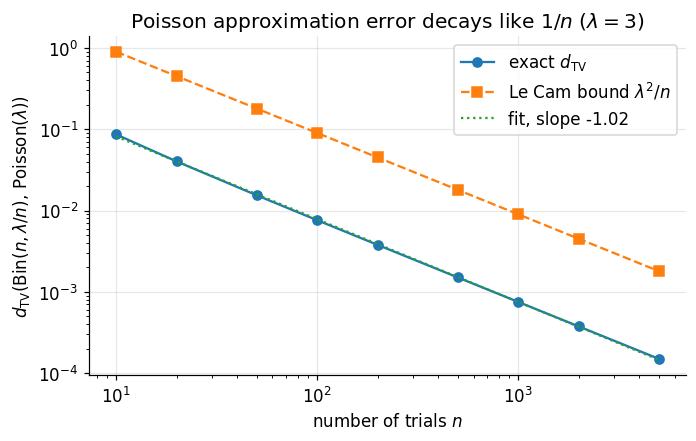

In [6]:
lam_fix = 3.0
ns = np.array([10, 20, 50, 100, 200, 500, 1000, 2000, 5000])
kk = np.arange(0, 400)
tvs = np.array([0.5 * np.sum(np.abs(binom.pmf(kk, int(n), lam_fix / n) - poisson.pmf(kk, lam_fix)))
                for n in ns])
bound = lam_fix**2 / ns

slope, intercept = np.polyfit(np.log(ns), np.log(tvs), 1)
print("    n      exact d_TV     Le Cam bound  ratio")
for n, t, b in zip(ns, tvs, bound):
    print(f"{n:6d}   {t:.3e}   {b:.3e}   {t/b:.3f}")
print(f"\nobserved order = {-slope:.4f}   predicted order = 1")
assert np.all(tvs <= bound + 1e-15)
assert abs(-slope - 1.0) < 0.05

fig, ax = plt.subplots()
ax.loglog(ns, tvs, "o-", label=r"exact $d_{\mathrm{TV}}$")
ax.loglog(ns, bound, "s--", label=r"Le Cam bound $\lambda^2/n$")
ax.loglog(ns, np.exp(intercept) * ns**slope, ":", label=f"fit, slope {slope:.2f}")
ax.set_xlabel("number of trials $n$")
ax.set_ylabel(r"$d_{\mathrm{TV}}\left(\mathrm{Bin}(n,\lambda/n),\,\mathrm{Poisson}(\lambda)\right)$")
ax.set_title(r"Poisson approximation error decays like $1/n$ ($\lambda = 3$)")
ax.legend()
plt.show()

The measured log-log slope is $-1.02$ against the predicted $-1$, and the exact distance stays
below the Le Cam ceiling at every $n$, at a nearly constant ratio of about $0.085$. So Theorem 4.5 has
the right *order* in $n$ and loses only a modest constant — which is what makes it usable as a
practical error bar rather than a qualitative statement.

### 7.4 Dropping a hypothesis

**Check (c).** Theorem 4.4 needs $p_n \to 0$. Hold $p = 0.4$ fixed instead and let $n$ grow: the
Poisson approximation must fail. For contrast, measure the Gaussian approximation error on the same
sequence. Also drop the equal-$p$ hypothesis of Theorem 4.2 and test whether the sum is still Binomial.

In [7]:
p_fixed = 0.4
print("no rarity: p = 0.4 fixed, lambda = np")
print("     n   d_TV(Bin, Poisson(np))   d_TV(Bin, Normal, cont.corrected)")
for n in [10, 50, 200, 1000]:
    kk = np.arange(0, 4 * n + 50)
    pb = binom.pmf(kk, n, p_fixed)
    tv_pois = 0.5 * np.sum(np.abs(pb - poisson.pmf(kk, n * p_fixed)))
    mu, sd = n * p_fixed, np.sqrt(n * p_fixed * (1 - p_fixed))
    pn = norm.cdf((kk + 0.5 - mu) / sd) - norm.cdf((kk - 0.5 - mu) / sd)
    tv_norm = 0.5 * np.sum(np.abs(pb - pn))
    print(f"{n:6d}   {tv_pois:20.4f}   {tv_norm:20.4f}")

# equal-p hypothesis of Theorem 4.2
m1, p1, n2, p2 = 20, 0.2, 30, 0.7
mean_s = m1 * p1 + n2 * p2
var_s = m1 * p1 * (1 - p1) + n2 * p2 * (1 - p2)
print(f"\nBin(20,0.2) + Bin(30,0.7): mean = {mean_s:.4f}, var = {var_s:.4f}")
print(f"any Binomial(N, pi) with this mean needs pi = 1 - var/mean = {1 - var_s/mean_s:.4f}, "
      f"N = mean/pi = {mean_s/(1 - var_s/mean_s):.4f}  -> not an integer, so no Binomial fits")
assert abs(mean_s / (1 - var_s / mean_s) - round(mean_s / (1 - var_s / mean_s))) > 1e-3

no rarity: p = 0.4 fixed, lambda = np
     n   d_TV(Bin, Poisson(np))   d_TV(Bin, Normal, cont.corrected)
    10                 0.1267                 0.0165
    50                 0.1239                 0.0073
   200                 0.1231                 0.0036
  1000                 0.1229                 0.0016

Bin(20,0.2) + Bin(30,0.7): mean = 25.0000, var = 9.5000
any Binomial(N, pi) with this mean needs pi = 1 - var/mean = 0.6200, N = mean/pi = 40.3226  -> not an integer, so no Binomial fits


Without rarity the Poisson error does **not** shrink: it plateaus at $d_{\mathrm{TV}} \approx 0.123$
and stays there however large $n$ becomes, while the continuity-corrected Gaussian error falls like
$n^{-1/2}$ (de Moivre–Laplace).
That is the breakage Theorem 4.4's hypothesis prevents: "many trials" alone selects the *Gaussian*
limit. Likewise the sum of two Binomials with different $p$ has a mean/variance pair that no Binomial
can match with integer $N$, confirming the closure condition of Theorem 4.2 is necessary, not merely
sufficient.

### 7.5 Hand-rolled against the library

**Check (d).** Implement the Binomial PMF twice — once naively through floating-point factorials,
once in log space with `lgamma` — and compare both against `scipy.stats.binom.pmf`.

In [8]:
def naive_factorial(n):
    """Factorial accumulated in double precision - overflows to inf past n = 170."""
    out = 1.0
    for i in range(2, n + 1):
        out *= i
    return out


def pmf_naive(n, k, p):
    return naive_factorial(n) / (naive_factorial(k) * naive_factorial(n - k)) * p**k * (1 - p) ** (n - k)


def pmf_log(n, k, p):
    log_c = lgamma(n + 1) - lgamma(k + 1) - lgamma(n - k + 1)
    return exp(log_c + k * np.log(p) + (n - k) * np.log1p(-p))


small = [(20, 7, 0.3), (40, 12, 0.55), (60, 30, 0.5)]
big = [(400, 200, 0.5), (2000, 1000, 0.5), (100000, 30000, 0.3)]

rel = 0.0
print(" n      k       naive           lgamma          scipy")
for n, k, p in small + big:
    a, b, c = pmf_naive(n, k, p), pmf_log(n, k, p), float(binom.pmf(k, n, p))
    rel = max(rel, abs(b - c) / c)
    print(f"{n:6d} {k:6d}   {a:.6e}   {b:.6e}   {c:.6e}")
print(f"\nmax relative deviation, lgamma implementation vs scipy = {rel:.3e}")
assert rel < 1e-9
assert not np.isfinite(pmf_naive(*big[1])) or np.isnan(pmf_naive(*big[1]))

 n      k       naive           lgamma          scipy
    20      7   1.642620e-01   1.642620e-01   1.642620e-01
    40     12   8.345838e-04   8.345838e-04   8.345838e-04
    60     30   1.025782e-01   1.025782e-01   1.025782e-01
   400    200   nan   3.986930e-02   3.986930e-02
  2000   1000   nan   1.783901e-02   1.783901e-02
100000  30000   nan   2.752955e-03   2.752955e-03

max relative deviation, lgamma implementation vs scipy = 4.595e-11


The log-space implementation matches SciPy to a relative $10^{-11}$ or better on every case, small and
large — the residual is the unavoidable cancellation in differencing three large `lgamma` values,
not a modelling error. The naive
version is fine up to $n \approx 170$ and then returns `nan` (it computes $\infty/\infty$), which is
the concrete failure Section 7.1 warns about: the *probability* is around $10^{-2}$ while the
*intermediate* factorials are around $10^{2568}$, far outside double range.

### 7.6 Finite-population correction, measured

**Check.** Confirm Theorem 4.8's Binomial limit by driving $N \to \infty$ at fixed $n$ and $K/N$.

In [9]:
n_draw, p_target = 5, 0.3
k_vals = np.arange(0, n_draw + 1)
pmf_target = binom.pmf(k_vals, n_draw, p_target)
prev = np.inf
print("     N   max|hypergeom - binomial|   fpc (N-n)/(N-1)")
for N in [20, 200, 2000, 20000]:
    K_pop = round(p_target * N)
    err = float(np.max(np.abs(hypergeom.pmf(k_vals, N, K_pop, n_draw) - pmf_target)))
    print(f"{N:6d}   {err:24.6e}   {(N-n_draw)/(N-1):.6f}")
    assert err < prev
    prev = err

     N   max|hypergeom - binomial|   fpc (N-n)/(N-1)
    20               4.346718e-02   0.789474
   200               3.731364e-03   0.979899
  2000               3.680548e-04   0.997999
 20000               3.675554e-05   0.999800


The maximum pointwise PMF error falls by roughly a decade per decade of $N$, and the
finite-population correction climbs to $1$ — the two halves of Theorem 4.8's limit statement,
measured rather than asserted.

### 7.7 A boxed answer from the exercises, recomputed

**Check.** Problem L3.2 claims the coupon-collector variance for $K = 50$ is $K^2\sum_{j \le K}j^{-2} - K H_K \approx 3838$, i.e. $\mathrm{sd} \approx 62$, and warns that the asymptotic $\pi^2K^2/6$ is a strict upper bound. Recompute both, and check against a Monte-Carlo run.

In [10]:
K = 50
j = np.arange(1, K + 1)
H_K = float(np.sum(1.0 / j))
S2 = float(np.sum(1.0 / j**2))
mean_T = K * H_K
var_exact = K**2 * S2 - K * H_K
var_naive = (pi**2 / 6) * K**2

trials, horizon = 20000, 1200
draws = rng.integers(0, K, size=(trials, horizon))
sim = np.empty(trials, dtype=np.int64)
for i in range(trials):
    seen = np.zeros(K, dtype=bool)
    n_seen = 0
    for t in range(horizon):
        x = draws[i, t]
        if not seen[x]:
            seen[x] = True
            n_seen += 1
            if n_seen == K:
                sim[i] = t + 1
                break

print(f"E[T] exact      = {mean_T:.3f}    Monte Carlo = {sim.mean():.3f}")
print(f"Var(T) exact    = {var_exact:.3f}    Monte Carlo = {sim.var():.3f}")
print(f"sd(T) exact     = {np.sqrt(var_exact):.3f}     asymptotic pi^2K^2/6 gives sd = {np.sqrt(var_naive):.3f}")
assert var_exact < var_naive
assert abs(sim.mean() - mean_T) < 2.0

E[T] exact      = 224.960    Monte Carlo = 225.319
Var(T) exact    = 3837.872    Monte Carlo = 3908.895
sd(T) exact     = 61.951     asymptotic pi^2K^2/6 gives sd = 64.127


The exact variance is $3837.9$, so $\mathrm{sd}(T) \approx 62.0$; the bound $\pi^2K^2/6$ would say
$64.1$. The Monte-Carlo mean lands within half a draw of $225.0$ and the sampled variance within
about $2\%$ of $3837.9$, confirming that the $-K H_K$ correction is real and that promoting a strict upper bound to an asymptotic equality is an error of
about $3\%$ in the standard deviation.

## 8. Applications

### 8.1 Machine learning

- **Every classifier head is a Categorical.** Softmax outputs parameterize $\text{Categorical}(\mathbf{p}(x))$ (Definition 3.7), and training by cross-entropy is exactly maximum likelihood for that law. Language models are the extreme case: one Categorical over a $50\text{k}$-token vocabulary per position.
- **Dropout is Bernoulli noise.** Multiplying activations by $\mathbf{1} \sim \text{Bernoulli}(1-p)$ injects variance $p/(1-p)$ per unit under inverted scaling — a regularizer whose strength is a variance, computable directly from Definition 3.1.
- **Negative sampling and subword sampling** draw from Categorical distributions over huge vocabularies via the alias method, often with tempered probabilities $p_j^{\alpha}$.
- **Count regression.** Poisson GLMs model click/impression/event counts with $\log E[Y \mid x] = \beta^{\top}x$; when the dispersion test of Definition 3.10 fails, Negative Binomial GLMs — equivalently the Gamma-mixed Poisson of Theorem 4.7 — absorb the excess variance.
- **Bayesian conjugacy.** Beta-Bernoulli and Dirichlet-Multinomial priors give closed-form posteriors, which is why "add-$\alpha$" smoothing in $n$-gram models is a posterior mean, not a hack.

### 8.2 Physics and engineering

- **Radioactive decay and photon counting.** Each of $N \approx 10^{20}$ nuclei decays in a short window with tiny probability; Theorem 4.4 collapses this Binomial into $\text{Poisson}(\lambda)$, and the $\sqrt{\lambda}$ standard deviation is the "shot noise" that limits every photon detector.
- **Detector efficiency is thinning.** A detector with quantum efficiency $q$ observes a thinned Poisson stream of rate $\lambda q$ (Theorem 4.7), which is why efficiency losses rescale the counting statistics without distorting them.
- **Statistical mechanics.** Occupation numbers of $n$ distinguishable classical particles over $K$ energy levels with Boltzmann weights are Multinomial, so $\mathrm{Cov}(N_i, N_j) = -np_ip_j \lt 0$ in the canonical ensemble; relaxing the fixed particle number (the grand canonical ensemble) makes the occupancies independent Poissons, and Theorem 4.7's thinning is the exact statement of that equivalence.
- **Reliability and queueing.** Geometric trials-to-failure models discrete-time reliability; the Poisson process — Poisson counts with exponential gaps, derived from axioms in Problem L3.3 — is the arrival model in the $M/M/1$ queue and in network traffic engineering.
- **Genetics and epidemiology.** Mutation counts per genome (Luria–Delbrück) and secondary infections per case in branching-process outbreak models are canonical Poisson/Negative-Binomial applications; the overdispersion parameter $r$ is precisely the "superspreading" parameter.

**Check.** Section 8.2 claims a Gamma-mixed Poisson is visibly wider than a plain Poisson at the same
mean, with dispersion index $1 + E[\Lambda]/r$. Simulate both and compare.

dispersion index, Poisson(8.0)        : 1.002   (theory 1.0)
dispersion index, Gamma-mixed Poisson  : 5.015   (theory 5.000)


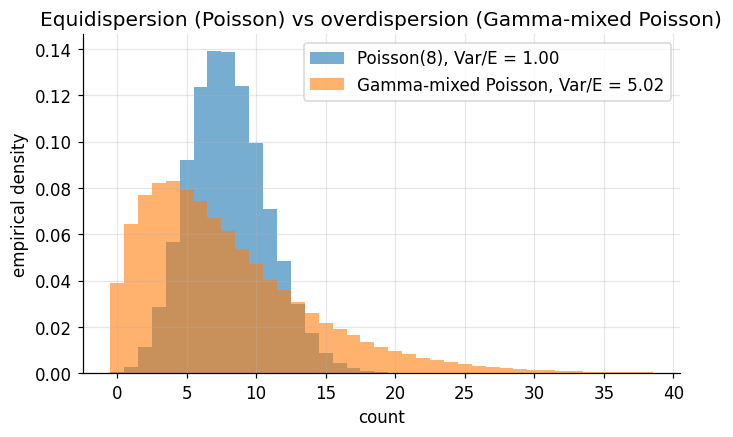

In [11]:
lam_target = 8.0
r_shape, beta_rate = 2.0, 2.0 / lam_target   # E[Lambda] = r/beta = lam_target
n_sim = 200_000

x_pois = rng.poisson(lam_target, size=n_sim)
lam_draw = rng.gamma(shape=r_shape, scale=1.0 / beta_rate, size=n_sim)
y_mixed = rng.poisson(lam_draw)

disp_pois = x_pois.var() / x_pois.mean()
disp_mixed = y_mixed.var() / y_mixed.mean()
print(f"dispersion index, Poisson({lam_target})        : {disp_pois:.3f}   (theory 1.0)")
print(f"dispersion index, Gamma-mixed Poisson  : {disp_mixed:.3f}   (theory {1 + lam_target/r_shape:.3f})")
assert abs(disp_pois - 1.0) < 0.05
assert abs(disp_mixed - (1 + lam_target / r_shape)) < 0.3

fig, ax = plt.subplots()
bins = np.arange(0, 40) - 0.5
ax.hist(x_pois, bins=bins, density=True, alpha=0.6, label=f"Poisson({lam_target:.0f}), Var/E = {disp_pois:.2f}")
ax.hist(y_mixed, bins=bins, density=True, alpha=0.6, label=f"Gamma-mixed Poisson, Var/E = {disp_mixed:.2f}")
ax.set_xlabel("count")
ax.set_ylabel("empirical density")
ax.set_title("Equidispersion (Poisson) vs overdispersion (Gamma-mixed Poisson)")
ax.legend()
plt.show()

The plain Poisson sample has dispersion index $\approx 1$ as Theorem 4.3 predicts; mixing the rate
over a Gamma prior widens the histogram and pushes the index to $\approx 5$, matching
$1 + E[\Lambda]/r$ from Theorem 4.7. This one number is the practical test that decides between
Poisson and Negative Binomial regression.

## 9. Key Takeaways

- For $S_n \sim \text{Binomial}(n,p)$: $E[S_n] = np$ needs only linearity, but $\mathrm{Var}(S_n) = np(1-p)$ needs independent trials with a common $p$ (Theorem 4.2).
- Independent Binomials with a **common** $p$ add to a Binomial; with different $p$ they do not (Theorem 4.2).
- If $X_n \sim \text{Binomial}(n,p_n)$ with $np_n \to \lambda \in (0,\infty)$ — so $p_n \to 0$ — then $P(X_n = k) \to \lambda^ke^{-\lambda}/k!$ for each fixed $k$ (Theorem 4.4); with $p$ fixed the limit is Gaussian instead.
- For **independent** Bernoulli$(p_i)$ summands with $\lambda = \sum_i p_i$: $d_{\mathrm{TV}}(S, \text{Poisson}(\lambda)) \le \sum_i p_i^2$, and the $\ell_1$ version is twice that (Theorem 4.5, Definition 3.9).
- A law on $\{1,2,\ldots\}$ with $P(T \lt \infty) = 1$ is memoryless if and only if it is Geometric (Theorem 4.6); the finiteness hypothesis is what rules out $T \equiv \infty$.
- Independent thinning of a Poisson($\lambda$) at rate $q$ yields independent Poisson($\lambda q$) and Poisson($\lambda(1-q)$) streams (Theorem 4.7).
- Mixing a Poisson rate over a non-degenerate $\Lambda$ gives $\mathrm{Var}(X) = E[X] + \mathrm{Var}(\Lambda) \gt E[X]$; with $\Lambda$ Gamma this is the failures-convention Negative Binomial of Definition 3.5 (Theorem 4.7).
- Sampling $n$ of $N$ without replacement keeps the mean $nK/N$ but multiplies the variance by the finite-population correction $(N-n)/(N-1) \le 1$ (Theorem 4.8).

## 10. References

| Source | Chapters / Sections | Coverage |
|---|---|---|
| Blitzstein & Hwang, *Introduction to Probability* (2nd ed.) | Chs. 3–4 | Generative stories, indicator tricks, the Poisson paradigm. |
| Ross, *A First Course in Probability* (10th ed.) | Ch. 4 (§4.6–4.8) | Binomial, Geometric, Negative Binomial, Poisson with worked examples. |
| Casella & Berger, *Statistical Inference* (2nd ed.) | §3.2 (Thm 3.2.1 ff.) | Common discrete families, MGFs, exponential-family structure. |
| Wasserman, *All of Statistics* | §2.4 | Compact catalogue of the important discrete laws. |
| Feller, *An Introduction to Probability Theory*, Vol. 1 (3rd ed.) | Ch. VI, Ch. XI | Bernoulli trials, occupancy problems, the Poisson approximation. |
| Bishop, *Pattern Recognition and Machine Learning* | §2.1–2.2 | Bernoulli/Multinomial with Beta and Dirichlet conjugate priors. |
| Murphy, *Probabilistic Machine Learning: An Introduction* | Ch. 2 (§2.4–2.5) | Discrete laws and the Categorical/softmax connection. |
| Le Cam (1960), *Pacific J. Math.* 10, 1181–1197 | Thm 1 | The total-variation bound for the Poisson approximation. |
| Durrett, *Probability: Theory and Examples* (5th ed.) | §3.6.1 (Thm 3.6.1) | Poisson convergence, Poisson processes, thinning. |

**Reading path**: Blitzstein & Hwang Chs. 3–4 for the stories, Casella & Berger §3.2 for the
generating-function machinery, Feller Ch. VI for the classical Poisson approximation, then Murphy
Ch. 2 for the Categorical-as-softmax bridge into deep learning.